In [1]:
# 3 candidates per slate
# 1 bloc of voters

# dirichlet
#U unif unif (2,2)
#S strong strong (1/2, 1/2)
#X unif strong (2, 1/2)
#Y strong unif (1/2, 2)

# CS W, CS C, sBT, sPL

# try L1 and earthmover

# 10 profiles, 1000 ballots each

# no axes labels, legend off plot

# range of cohesion for B, .55 through .95 by .1

In [1]:
import votekit.ballot_generator as bg
from votekit.plots import plot_MDS, compute_MDS
from votekit.metrics import earth_mover_dist, lp_dist
from votekit import Ballot, PreferenceProfile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [2]:
def extend_ballots(pp: PreferenceProfile, num_cands:int):
    """
    Turn ballots of max length-1 into ballots of max length.
    Assumes no ties.

    Args:
        pp (PrefProfile): profile
        num_cands (int): total number of candidates, ie max ballot length

    Returns: 
        PreferenceProfile
    
    """

    # identify n-1 ballots with n 
    new_ballots = [Ballot() for _ in range(pp.num_ballots)]

    for i, ballot in enumerate(pp.ballots):
        for s in ballot.ranking:
            if len(s) >1:
                raise TypeError("Ballots must have no ties.")
            
        if len(ballot.ranking) == num_cands-1:
            ballot_cands = [c for s in ballot.ranking for c in s]
            missing_cand = set(pp.candidates).difference(ballot_cands)
            new_ranking = ballot.ranking +(missing_cand,)

            new_ballots[i] = Ballot(ranking = new_ranking, weight = ballot.weight)


        else:
            new_ballots[i] = ballot

    return PreferenceProfile(ballots = new_ballots, candidates = pp.candidates).condense_ballots()


In [3]:
# constants

pref_scenario_settings = {"U": {"A":2, "B":2 }, 
                          "X":{"A":2, "B":1/2 },
                            "Y":{"A":1/2, "B":2 },
                              "S":{"A":1/2, "B":1/2 }}

pref_scenario_markers = {"U": "$\mathdefault{U}$", 
                          "X":"$\mathdefault{X}$",
                            "Y":"$\mathdefault{Y}$",
                              "S":"$\mathdefault{S}$"}

pref_scenarios = list(pref_scenario_settings.keys())
cand_per_slate = 3
num_profiles = 10
num_ballots = 1000
b_coh_list  = [.55, .65, .75, .85, .95]
bloc_voter_prop = {"A":0, "B": 1}
slate_to_candidates = {"A": [f"A_{i}" for i in range(cand_per_slate)],
                       "B": [f"B_{i}" for i in range(cand_per_slate)]}
model_to_color = {'CS-C': '#D2691E', 'CS-W': '#E32636', 's-BT': '#FFBF00', 's-PL': '#8DB600'}
models = list(model_to_color.keys())
profile_dict = {(m, s, b_coh) :[] for m in models for s in pref_scenarios for b_coh in b_coh_list}



In [4]:
# generate profiles

for pref_scenario_str, b_alphas in pref_scenario_settings.items():
    for model in models:
        for b_coh in b_coh_list:
            if model == "CS-C":
                g = bg.CambridgeSampler.from_params(slate_to_candidates=slate_to_candidates,
                        bloc_voter_prop=bloc_voter_prop,
                        cohesion_parameters={"A": {"A": 1, "B": 0},
                                             "B": {"A":1-b_coh, "B":b_coh}},
                        alphas={"A": {"A":1, "B":1},
                                "B": b_alphas},
                        W_bloc = "A",
                        C_bloc = "B")

            elif model == "CS-W":
                g = bg.CambridgeSampler.from_params(slate_to_candidates=slate_to_candidates,
                        bloc_voter_prop=bloc_voter_prop,
                        cohesion_parameters={"A": {"A": 1, "B": 0},
                                             "B": {"A":1-b_coh, "B":b_coh}},
                        alphas={"A": {"A":1, "B":1},
                                "B": b_alphas},
                        W_bloc = "B",
                        C_bloc = "A")
            
            elif model == "s-BT":
                g = bg.slate_BradleyTerry.from_params(slate_to_candidates=slate_to_candidates,
                        bloc_voter_prop=bloc_voter_prop,
                        cohesion_parameters={"A": {"A": 1, "B": 0},
                                             "B": {"A":1-b_coh, "B":b_coh}},
                        alphas={"A": {"A":1, "B":1},
                                "B": b_alphas},)

            elif model == "s-PL":
                g = bg.slate_PlackettLuce.from_params(slate_to_candidates=slate_to_candidates,
                        bloc_voter_prop=bloc_voter_prop,
                        cohesion_parameters={"A": {"A": 1, "B": 0},
                                             "B": {"A":1-b_coh, "B":b_coh}},
                        alphas={"A": {"A":1, "B":1},
                                "B": b_alphas},)

            else:
                raise ValueError("invalid generator")
            
        
            
                
            profile_dict[(model, pref_scenario_str, b_coh)] = [extend_ballots(pp= g.generate_profile(num_ballots), num_cands = 2*cand_per_slate) for _ in range(num_profiles)]



In [5]:
# try L1 distance first
b_coh = .75
coord_dict_l1 = compute_MDS(data = {k:v for k,v in profile_dict.items() if k[2]==b_coh},
            distance = lp_dist, # default is p=1
            )

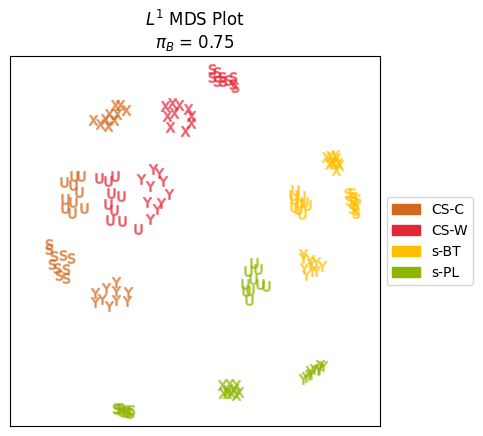

In [8]:
ax = plot_MDS(coord_dict=coord_dict_l1,
                plot_kwarg_dict={(model, pref_scenario, b_coh): {"c": model_to_color[model], "s":50, "marker":pref_scenario_markers[pref_scenario], "alpha" :.5} 
                                            for model in models for pref_scenario in pref_scenarios},
                legend = False, title = False)

plt.title(r"$L^1$ MDS Plot"+"\n"+r"$\pi_B$ = "+f"{b_coh}")
# Create a list of patches for the legend
patches = [mpatches.Patch(color=color, label=label) for label, color in model_to_color.items()]
plt.legend(handles=patches, loc='center left', bbox_to_anchor=(1, 1/2))
plt.show()


In [9]:
coord_dict_l1 = {}
for b_coh in b_coh_list:
    coord_dict_l1[b_coh] = compute_MDS(data = {k:v for k,v in profile_dict.items() if k[2]==b_coh},
                distance = lp_dist, # default is p=1
                )


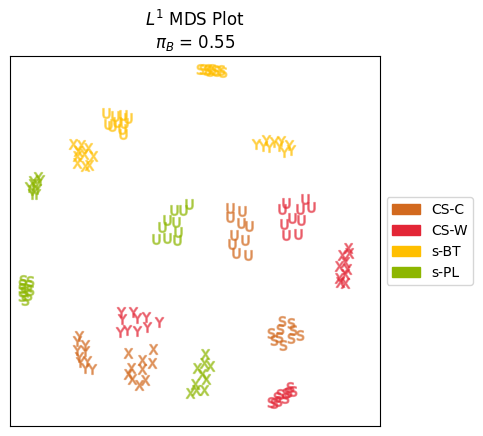

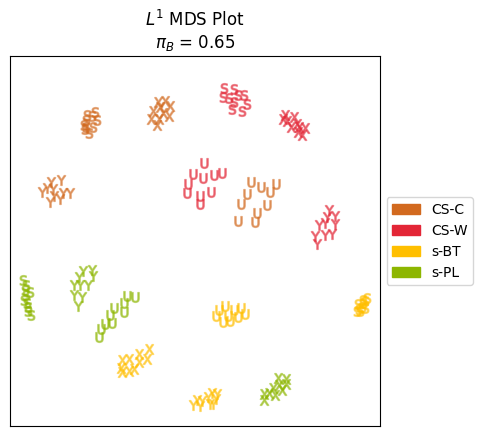

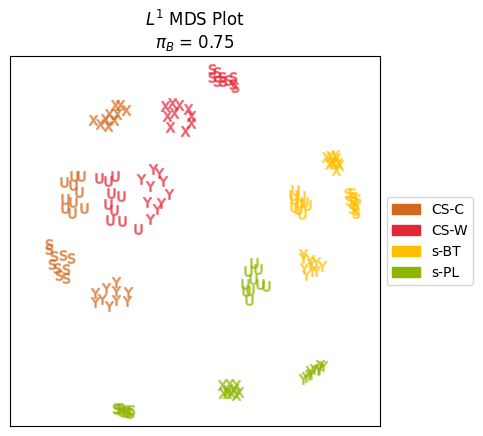

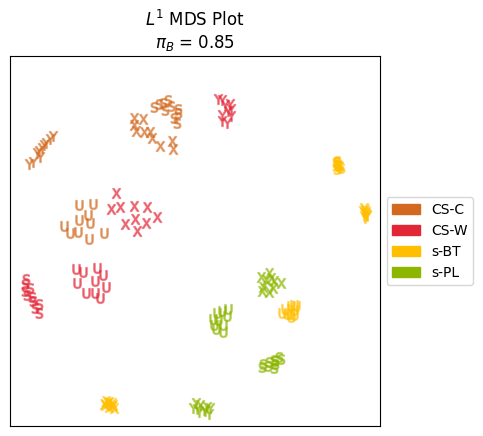

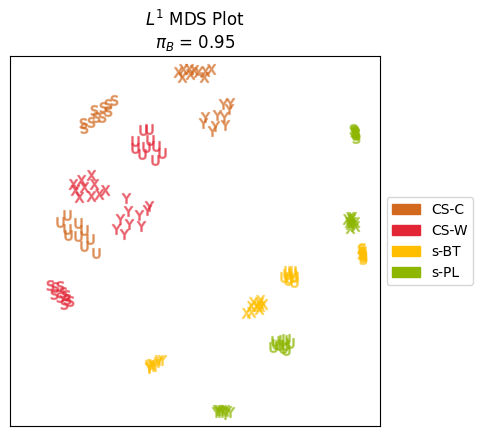

In [10]:
for b_coh in b_coh_list:
    ax = plot_MDS(coord_dict=coord_dict_l1[b_coh],
                plot_kwarg_dict={(model, pref_scenario, b_coh): {"c": model_to_color[model], "s":50, "marker":pref_scenario_markers[pref_scenario], "alpha" :.5} 
                                            for model in models for pref_scenario in pref_scenarios},
                legend = False, title = False)

    plt.title(r"$L^1$ MDS Plot"+"\n"+r"$\pi_B$ = "+f"{b_coh}")
    # Create a list of patches for the legend
    patches = [mpatches.Patch(color=color, label=label) for label, color in model_to_color.items()]
    plt.legend(handles=patches, loc='center left', bbox_to_anchor=(1, 1/2))
    # plt.show()
    plt.savefig(f"Figures/mds_plot_l1_b_coh_{b_coh}.png", dpi=300)

In [17]:
# try EMD
# the data is a dictionary whose keys correspond to data labels
# and whose values are lists of PreferenceProfiles
b_coh = .75
coord_dict_emd = compute_MDS(data = {k:v for k,v in profile_dict.items() if k[2]==b_coh},
            distance = earth_mover_dist, 
            )

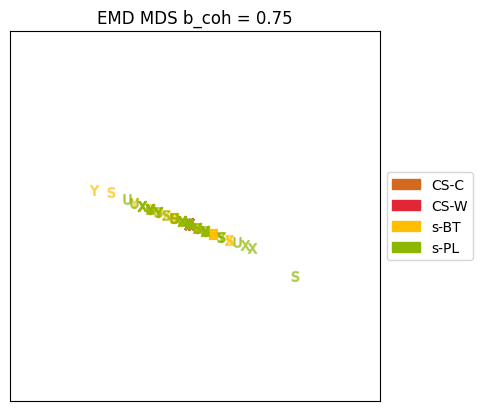

In [18]:
ax = plot_MDS(coord_dict=coord_dict_emd,
                plot_kwarg_dict={(model, pref_scenario, b_coh): {"c": model_to_color[model], "s":50, "marker":pref_scenario_markers[pref_scenario], "alpha" :.5} 
                                            for model in models for pref_scenario in pref_scenarios},
                legend = False, title = False)

plt.title(f"EMD MDS b_coh = {b_coh}")
# Create a list of patches for the legend
patches = [mpatches.Patch(color=color, label=label) for label, color in model_to_color.items()]
plt.legend(handles=patches, loc='center left', bbox_to_anchor=(1, 1/2))
plt.show()

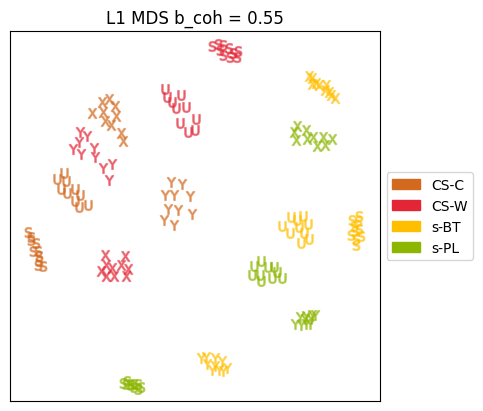

In [10]:
import pickle
b_coh = .55
with open('coords/mds_coords_l1_b_coh_0.55.pickle', 'rb') as handle:
    loaded_dict = pickle.load(handle)

ax = plot_MDS(coord_dict=loaded_dict,
                plot_kwarg_dict={(model, pref_scenario): {"c": model_to_color[model], "s":50, "marker":pref_scenario_markers[pref_scenario], "alpha" :.5} 
                                            for model in models for pref_scenario in pref_scenarios},
                legend = False, title = False)

plt.title(f"L1 MDS b_coh = {b_coh}")
# Create a list of patches for the legend
patches = [mpatches.Patch(color=color, label=label) for label, color in model_to_color.items()]
plt.legend(handles=patches, loc='center left', bbox_to_anchor=(1, 1/2))
plt.show()